**7**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 24s 14ms/step - accuracy: 0.2746 - loss: 2.1243 - val_accuracy: 0.3292 - val_loss: 1.8975
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 14ms/step - accuracy: 0.3225 - loss: 1.8774 - val_accuracy: 0.3740 - val_loss: 1.7658


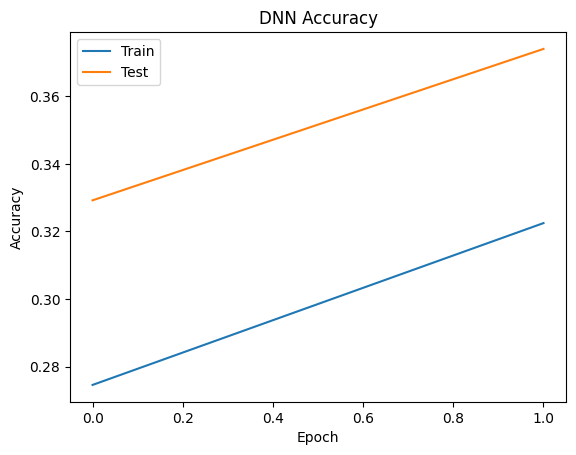

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers,models
from tensorflow.keras.datasets import cifar10

# Load Data
(x_train,y_train),(x_test,y_test)=cifar10.load_data()

# Normalize
x_train,x_test=x_train/255.0,x_test/255.0

# DNN Model
model=models.Sequential([
    layers.Flatten(input_shape=(32,32,3)),

    layers.Dense(256,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(128,activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),

    layers.Dense(10,activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history=model.fit(x_train,y_train,
                  epochs=2,
                  validation_data=(x_test,y_test))

# Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title("DNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Test'])
plt.show()

**8**

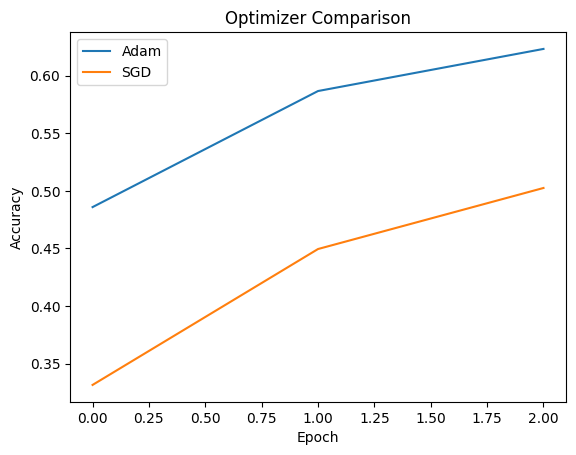

In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers,models
from tensorflow.keras.datasets import cifar10

# Load Data
(x_train,y_train),(x_test,y_test)=cifar10.load_data()

# Normalize
x_train,x_test=x_train/255.0,x_test/255.0

# CNN Function
def create_model():
    model=models.Sequential([
        layers.Input(shape=(32,32,3)),
        layers.Conv2D(32,(3,3),activation='relu'),
        layers.MaxPooling2D(),
        layers.Flatten(),
        layers.Dense(10,activation='softmax')
    ])
    return model

# Adam
model1=create_model()
model1.compile(optimizer='adam',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

h1=model1.fit(x_train,y_train,epochs=3,verbose=0)

# SGD
model2=create_model()
model2.compile(optimizer='sgd',
               loss='sparse_categorical_crossentropy',
               metrics=['accuracy'])

h2=model2.fit(x_train,y_train,epochs=3,verbose=0)

# Graph
plt.plot(h1.history['accuracy'])
plt.plot(h2.history['accuracy'])

plt.title("Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Adam','SGD'])
plt.show()

**9**

Using CPU
Epoch 1/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 17ms/step - accuracy: 0.9341 - loss: 0.2251 - val_accuracy: 0.9754 - val_loss: 0.0850
Epoch 2/2
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 18ms/step - accuracy: 0.9753 - loss: 0.0816 - val_accuracy: 0.9825 - val_loss: 0.0549


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step
Predicted Digit : 7


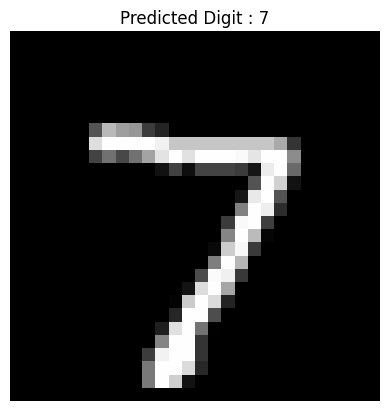

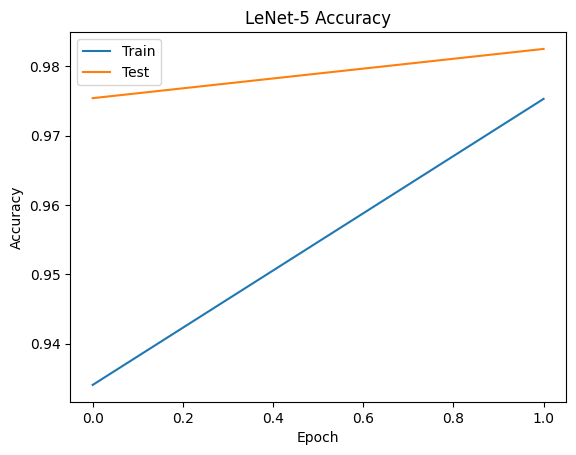

In [ ]:
# LeNet-5 using CPU

import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import layers,models
from tensorflow.keras.datasets import mnist

print("Using CPU")

# Load Dataset
(x_train,y_train),(x_test,y_test)=mnist.load_data()

# Normalize
x_train=x_train/255.0
x_test=x_test/255.0

# Reshape
x_train=x_train.reshape(-1,28,28,1)
x_test=x_test.reshape(-1,28,28,1)

# LeNet-5 Model
model=models.Sequential([

    layers.Input(shape=(28,28,1)),

    layers.Conv2D(6,(5,5),activation='relu'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Conv2D(16,(5,5),activation='relu'),
    layers.AveragePooling2D(pool_size=(2,2)),

    layers.Flatten(),

    layers.Dense(120,activation='relu'),
    layers.Dense(84,activation='relu'),

    layers.Dense(10,activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history=model.fit(
    x_train,
    y_train,
    epochs=2,
    validation_data=(x_test,y_test)
)

# Predict
pred=model.predict(x_test[:1])

print("Predicted Digit :",pred.argmax())

# Show Image
plt.imshow(x_test[0].reshape(28,28),cmap='gray')
plt.title("Predicted Digit : "+str(pred.argmax()))
plt.axis("off")
plt.show()

# Accuracy Graph
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("LeNet-5 Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend(['Train','Test'])

plt.show()

**10**

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 164s 104ms/step - accuracy: 0.5011 - loss: 1.3941 - val_accuracy: 0.6081 - val_loss: 1.1342
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 203s 105ms/step - accuracy: 0.6428 - loss: 1.0163 - val_accuracy: 0.6615 - val_loss: 0.9748


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step


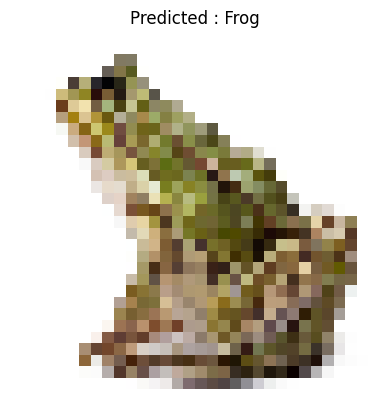

In [ ]:
# AlexNet Image Classification using Custom Image

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.preprocessing import image

# CIFAR10 Class Names
classes = ['Airplane','Automobile','Bird','Cat','Deer',
           'Dog','Frog','Horse','Ship','Truck']

# Load Dataset
(x_train,y_train),(x_test,y_test)=cifar10.load_data()

# Normalize
x_train,x_test=x_train/255.0,x_test/255.0

# AlexNet-like Model
model=models.Sequential([
    layers.Input(shape=(32,32,3)),

    layers.Conv2D(64,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128,(3,3),activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128,activation='relu'),
    layers.Dense(10,activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train Model
history=model.fit(x_train,y_train,
                  epochs=2,
                  validation_data=(x_test,y_test))

# -------- IMAGE CLASSIFICATION --------

# Load Your Image
img=image.load_img("frog.jpg",target_size=(32,32))

# Convert Image to Array
img_array=image.img_to_array(img)/255.0
img_array=np.expand_dims(img_array,axis=0)

# Predict
prediction=model.predict(img_array)

# Get Class
predicted_class=classes[np.argmax(prediction)]

# Show Image
plt.imshow(img)
plt.title("Predicted : "+predicted_class)
plt.axis("off")
plt.show()

**11**

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step
Predicted Word : powerful


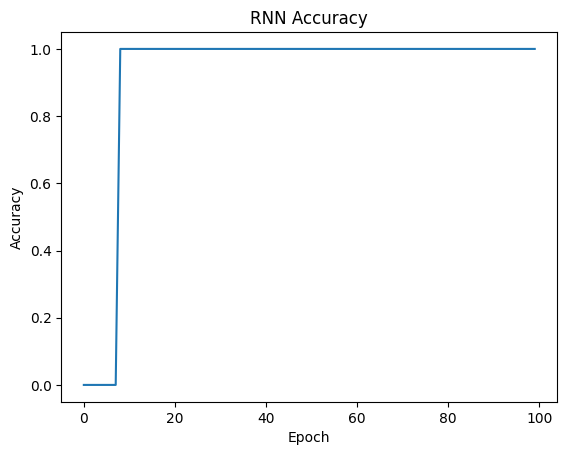

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,SimpleRNN,Dense

# Text
text=["deep learning is powerful"]

# Tokenize
tok=Tokenizer()
tok.fit_on_texts(text)

seq=tok.texts_to_sequences(text)[0]

X=np.array([seq[:3]])
y=np.array([seq[3]])

# Model
model=Sequential([
    Embedding(20,8,input_length=3),
    SimpleRNN(16),
    Dense(20,activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history=model.fit(X,y,epochs=100,verbose=0)

# Predict
pred=np.argmax(model.predict(X),axis=1)

# Display Word
print("Predicted Word :",tok.index_word[pred[0]])

# Graph
plt.plot(history.history['accuracy'])
plt.title("RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()

**12**

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step
Generated Text : artificial intelligence is amazing


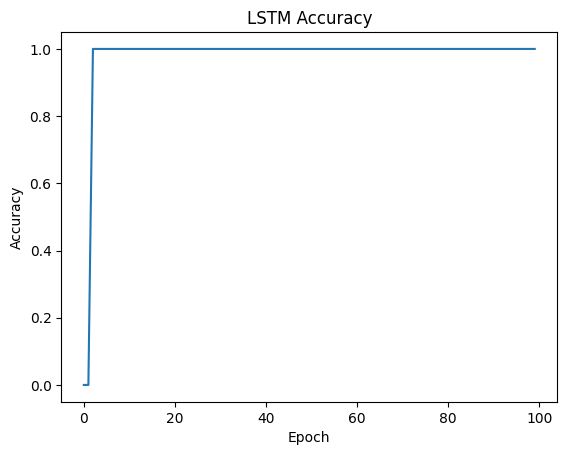

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense
from tensorflow.keras.preprocessing.text import Tokenizer

# Text
text=["artificial intelligence is amazing"]

# Tokenize
tok=Tokenizer()
tok.fit_on_texts(text)

seq=tok.texts_to_sequences(text)[0]

# Input and Output
X=np.array([seq[:3]])
y=np.array([seq[3]])

# Model
model=Sequential([
    Embedding(20,8,input_length=3),
    LSTM(32),
    Dense(20,activation='softmax')
])

# Compile
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train
history=model.fit(X,y,epochs=100,verbose=0)

# Predict
pred=np.argmax(model.predict(X),axis=1)

# Convert Index to Word
word=tok.index_word[pred[0]]

# Generated Text
input_text="artificial intelligence is"
generated_text=input_text+" "+word

print("Generated Text :",generated_text)

# Graph
plt.plot(history.history['accuracy'])
plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.show()